In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('products_asos.csv')

df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

print(f"number of rows: {len(df)} rows and number of columns: {len(df.columns)} columns")

df.head(5)


number of rows: 18378 rows and number of columns: 9 columns


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18378 entries, 0 to 30844
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   url          18378 non-null  object 
 1   name         18378 non-null  object 
 2   size         18378 non-null  object 
 3   category     18378 non-null  object 
 4   price        18378 non-null  float64
 5   color        18378 non-null  object 
 6   sku          18378 non-null  float64
 7   description  18378 non-null  object 
 8   images       18378 non-null  object 
dtypes: float64(2), object(7)
memory usage: 1.4+ MB


In [4]:
df['description'] = df['description'].astype(str)
df['name'] = df['name'].astype(str)
# getting brand name from name column, where the brand name can be either the first word for brands like 'ASOS' and 'Topshop' or the first two words for the rest of the brands
df['brand'] = df['name'].apply(lambda x: x.split()[0] if x.split()[0] in ['ASOS', 'Topshop','Nike', 'Stradivarius','JDY'] else ' '.join(x.split()[:2]))


df.head(5)

,url,name,size,category,price,color,sku,description,images,brand
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,Stradivarius


In [5]:
df.tail(5)

,url,name,size,category,price,color,sku,description,images,brand
30840,https://www.asos.com/urban-revivo/urban-revivo...,Urban Revivo square neck mini dress in floral ...,"XS - UK 6 - Out of stock,S - UK 8 - Out of sto...",Urban Revivo square neck mini dress in floral ...,44.00,Multi,116745746.0,[{'Product Details': 'Mini dress by Urban Revi...,['https://images.asos-media.com/products/urban...,Urban Revivo
30841,https://www.asos.com/asos-design/asos-design-l...,ASOS DESIGN long sleeve maxi t-shirt dress in ...,"UK 4 - Out of stock,UK 6 - Out of stock,UK 8 -...",ASOS DESIGN long sleeve maxi t-shirt dress in ...,24.00,Black,1444255.0,[{'Product Details': 'Dress by ASOS DESIGN Act...,['https://images.asos-media.com/products/asos-...,ASOS
30842,https://www.asos.com/asyou/asyou-layered-t-shi...,ASYOU layered t-shirt dress with focus graphic...,"UK 4 - Out of stock,UK 6,UK 8 - Out of stock,U...",ASYOU layered t-shirt dress with focus graphic...,22.99,Washed black,110783769.0,[{'Product Details': 'Dress by ASYOU Exclusive...,['https://images.asos-media.com/products/asyou...,ASYOU layered
30843,https://www.asos.com/miss-selfridge/miss-selfr...,Miss Selfridge Petite rib knit frill hem funne...,"UK 4 - Out of stock,UK 6 - Out of stock,UK 8 -...",Miss Selfridge Petite rib knit frill hem funne...,32.99,BLACK,116363729.0,[{'Product Details': 'Petite by Miss Selfridge...,['https://images.asos-media.com/products/miss-...,Miss Selfridge
30844,https://www.asos.com/other-stories/other-stori...,& Other Stories plisse mesh midi dress in blac...,"XS - UK 4-6 - Out of stock,S - UK 8-10,M - UK ...",& Other Stories plisse mesh midi dress in blac...,65.00,Black and white,124159122.0,[{'Product Details': 'Dresses by & Other Stori...,['https://images.asos-media.com/products/other...,& Other


number of unique brands: 2363
Top 10 brands:
brand
ASOS                4842
Topshop             1136
River Island         469
New Look             467
Miss Selfridge       426
Stradivarius         345
Vero Moda            327
Nike                 303
adidas Originals     248
& Other              224
Name: count, dtype: int64


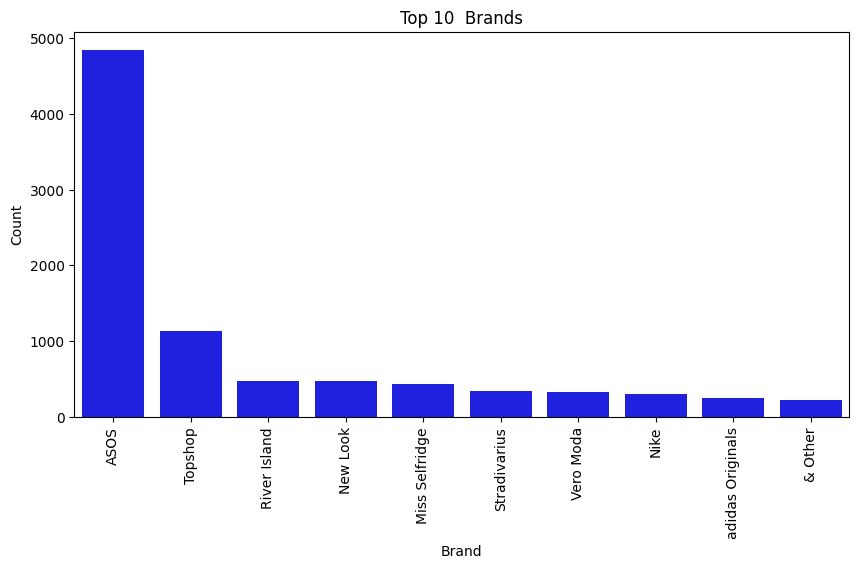

In [6]:
# counting the number of times each brand appears in the dataset
brand_counts = df['brand'].value_counts()
#print the number of unique brands in the dataset
print(f"number of unique brands: {len(brand_counts)}")
# getting the top 10 brands
top_10_brands = brand_counts.head(10)
print("Top 10 brands:")
print(top_10_brands)
# getting the last 10 brands
last_10_brands = brand_counts.tail(10)
# plotting the top 10 brands in blue color
plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_brands.index, y=top_10_brands.values, color='blue')
plt.title('Top 10  Brands')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.show()

Stock Status:
stock
Out of stock    9862
In stock        8516
Name: count, dtype: int64


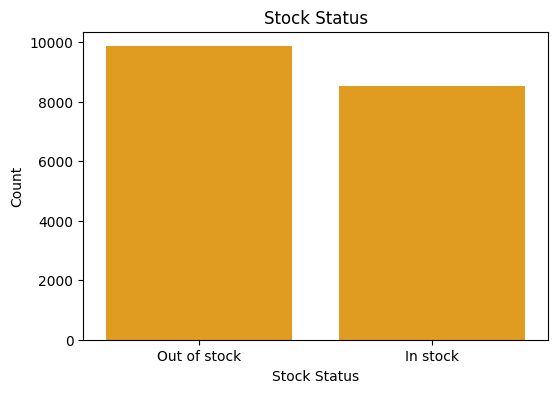

,url,name,size,category,price,color,sku,description,images,brand,stock
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look,Out of stock
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look,Out of stock
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look,Out of stock
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New Look,Out of stock
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,Stradivarius,In stock


In [7]:
# analyzing stocks, looking at the 'size' column, some sizes in the size column  are in the format 'UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stock,UK 16,UK 18' that indicates that the size UK 14 is out of the stock
# and others are in the format 'UK 4,UK 6,UK 8,UK 10,UK 12,UK 14,UK 16,UK 18,UK 20' indicating that all sizes are availaible in the stock, so we can create a new column 'stock' that indicates whether the product is in stock or out of stock based on the presence of 'Out of stock' in the 'size' column
df['stock'] = df['size'].apply(lambda x: 'Out of stock' if 'Out of stock' in x else 'In stock')

#count how many items are out of stock and those in stock 
stock_counts = df['stock'].value_counts()

print("Stock Status:")
print(stock_counts)

# plotting the stock status in orange color
plt.figure(figsize=(6, 4))
sns.barplot(x=stock_counts.index, y=stock_counts.values, color='orange')
plt.title('Stock Status')
plt.xlabel('Stock Status')
plt.ylabel('Count')

plt.show()

df.head()

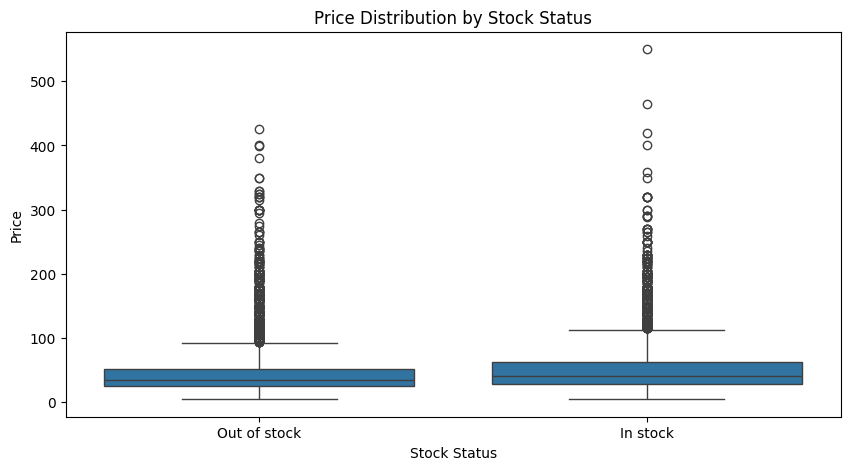

In [8]:
# assuming that the products that are out of stock are the products that are the most popular, we can analyze the price distribution of the products that are out of stock and those in stock to see if there is a difference in price between the two groups
plt.figure(figsize=(10, 5))
sns.boxplot(x='stock', y='price', data=df)
plt.title('Price Distribution by Stock Status')
plt.xlabel('Stock Status')
plt.ylabel('Price')
plt.show()

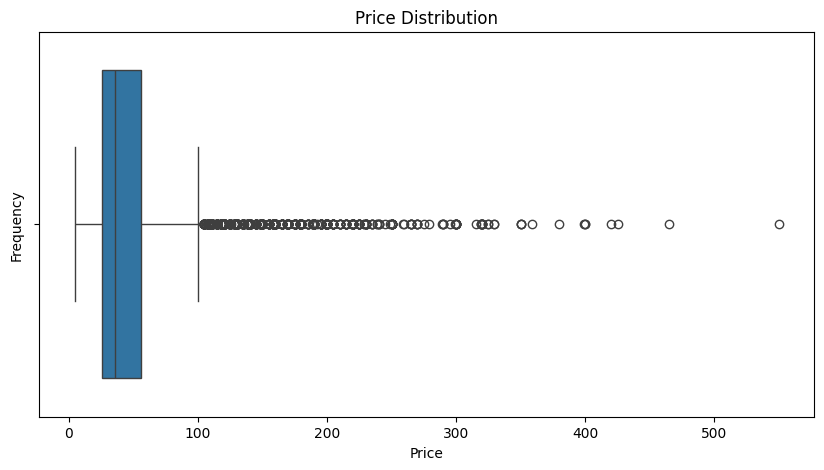

In [9]:
# analyzing the price distribution, looking at the 'price' column, we can see that there are some outliers in the price column, so we can create a box plot to visualize the price distribution and identify the outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'])
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()




In [11]:
# finding the brands that have the most products in the dataset that are out of stock, we can group the dataset by the 'brand' column and count the number of products that are out of stock for each brand, then we can sort the results in descending order to find the brands with the most products that are out of stock
out_of_stock_brands = df[df['stock'] == 'Out of stock'].groupby('brand').size().sort_values(ascending=False)
print("Brands with the most products that are out of stock:")
print(out_of_stock_brands.head(10))

Brands with the most products that are out of stock:
brand
ASOS                 2671
Topshop               609
New Look              339
River Island          268
Stradivarius          219
Miss Selfridge        218
Vero Moda             216
adidas Originals      146
& Other               126
Reclaimed Vintage     121
dtype: int64


In [12]:
# finding out if the brands with the most products that are out of stock are also the brands with the most expensive products, we can group the dataset by the 'brand' column and calculate the average price for each brand, then we can sort the results in descending order to find the brands with the most expensive products and compare it with the brands that have the most products that are out of stock
average_price_by_brand = df.groupby('brand')['price'].mean().sort_values(ascending=False)
print("Brands with the most expensive products:")
print(average_price_by_brand.head(10))

print("Brands with the least expensive products:")
print(average_price_by_brand.tail(10))


Brands with the most expensive products:
brand
Napapijri skidoo       420.000000
AllSaints Benyon       359.000000
Roxy Peak              350.000000
AllSaints caden        329.000000
AllSaints Elora        319.000000
HUGO polyester         319.000000
AllSaints Balfern      319.000000
Napapijri x            316.666667
Fiorucci balconette    275.000000
Napapijri a-harness    265.000000
Name: price, dtype: float64
Brands with the least expensive products:
brand
Fashionkilla adhesive    7.666667
Hunkemoller Kim          7.000000
Monki Edina              7.000000
COLLUSION t-shirt        6.990000
Monki halfstring         6.000000
Monki halterneck         6.000000
Monki thong              6.000000
COLLUSION crop           5.990000
ASYOU bralet             4.990000
COLLUSION halter         4.990000
Name: price, dtype: float64


brand         & Other  ASOS  Miss Selfridge  New Look  Nike  River Island  \
stock                                                                       
In stock           98  2171             208       128   190           201   
Out of stock      126  2671             218       339   113           268   

brand         Stradivarius  Topshop  Vero Moda  adidas Originals  
stock                                                             
In stock               126      527        111               102  
Out of stock           219      609        216               146  
Chi-square statistic: 125.59253503694246
p-value: 9.539831276436061e-23


<Axes: xlabel='brand'>

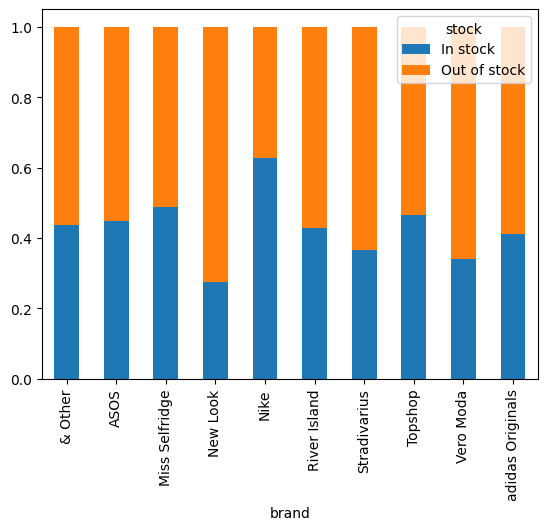

In [19]:
# finding out if there is a relationship between the stock status and the brand,specifically the top_10_brands, we can create a crosstab to see the relationship between the two variables and then we can use a chi-square test to determine if there is a significant relationship between the stock status and the brand
top_10_brands = df['brand'].value_counts().head(10).index.tolist()
df_top = df[df['brand'].isin(top_10_brands)]
crosstab = pd.crosstab(df_top['stock'], df_top['brand'])
print(crosstab)
# using a chi-square test to determine if there is a significant relationship between the stock status and the brand
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(crosstab)
print(f"Chi-square statistic: {chi2}")
print(f"p-value: {p}")

#
crosstab_norm = crosstab.div(crosstab.sum(axis=0), axis=1)
crosstab_norm.T.plot(kind='bar', stacked=True)


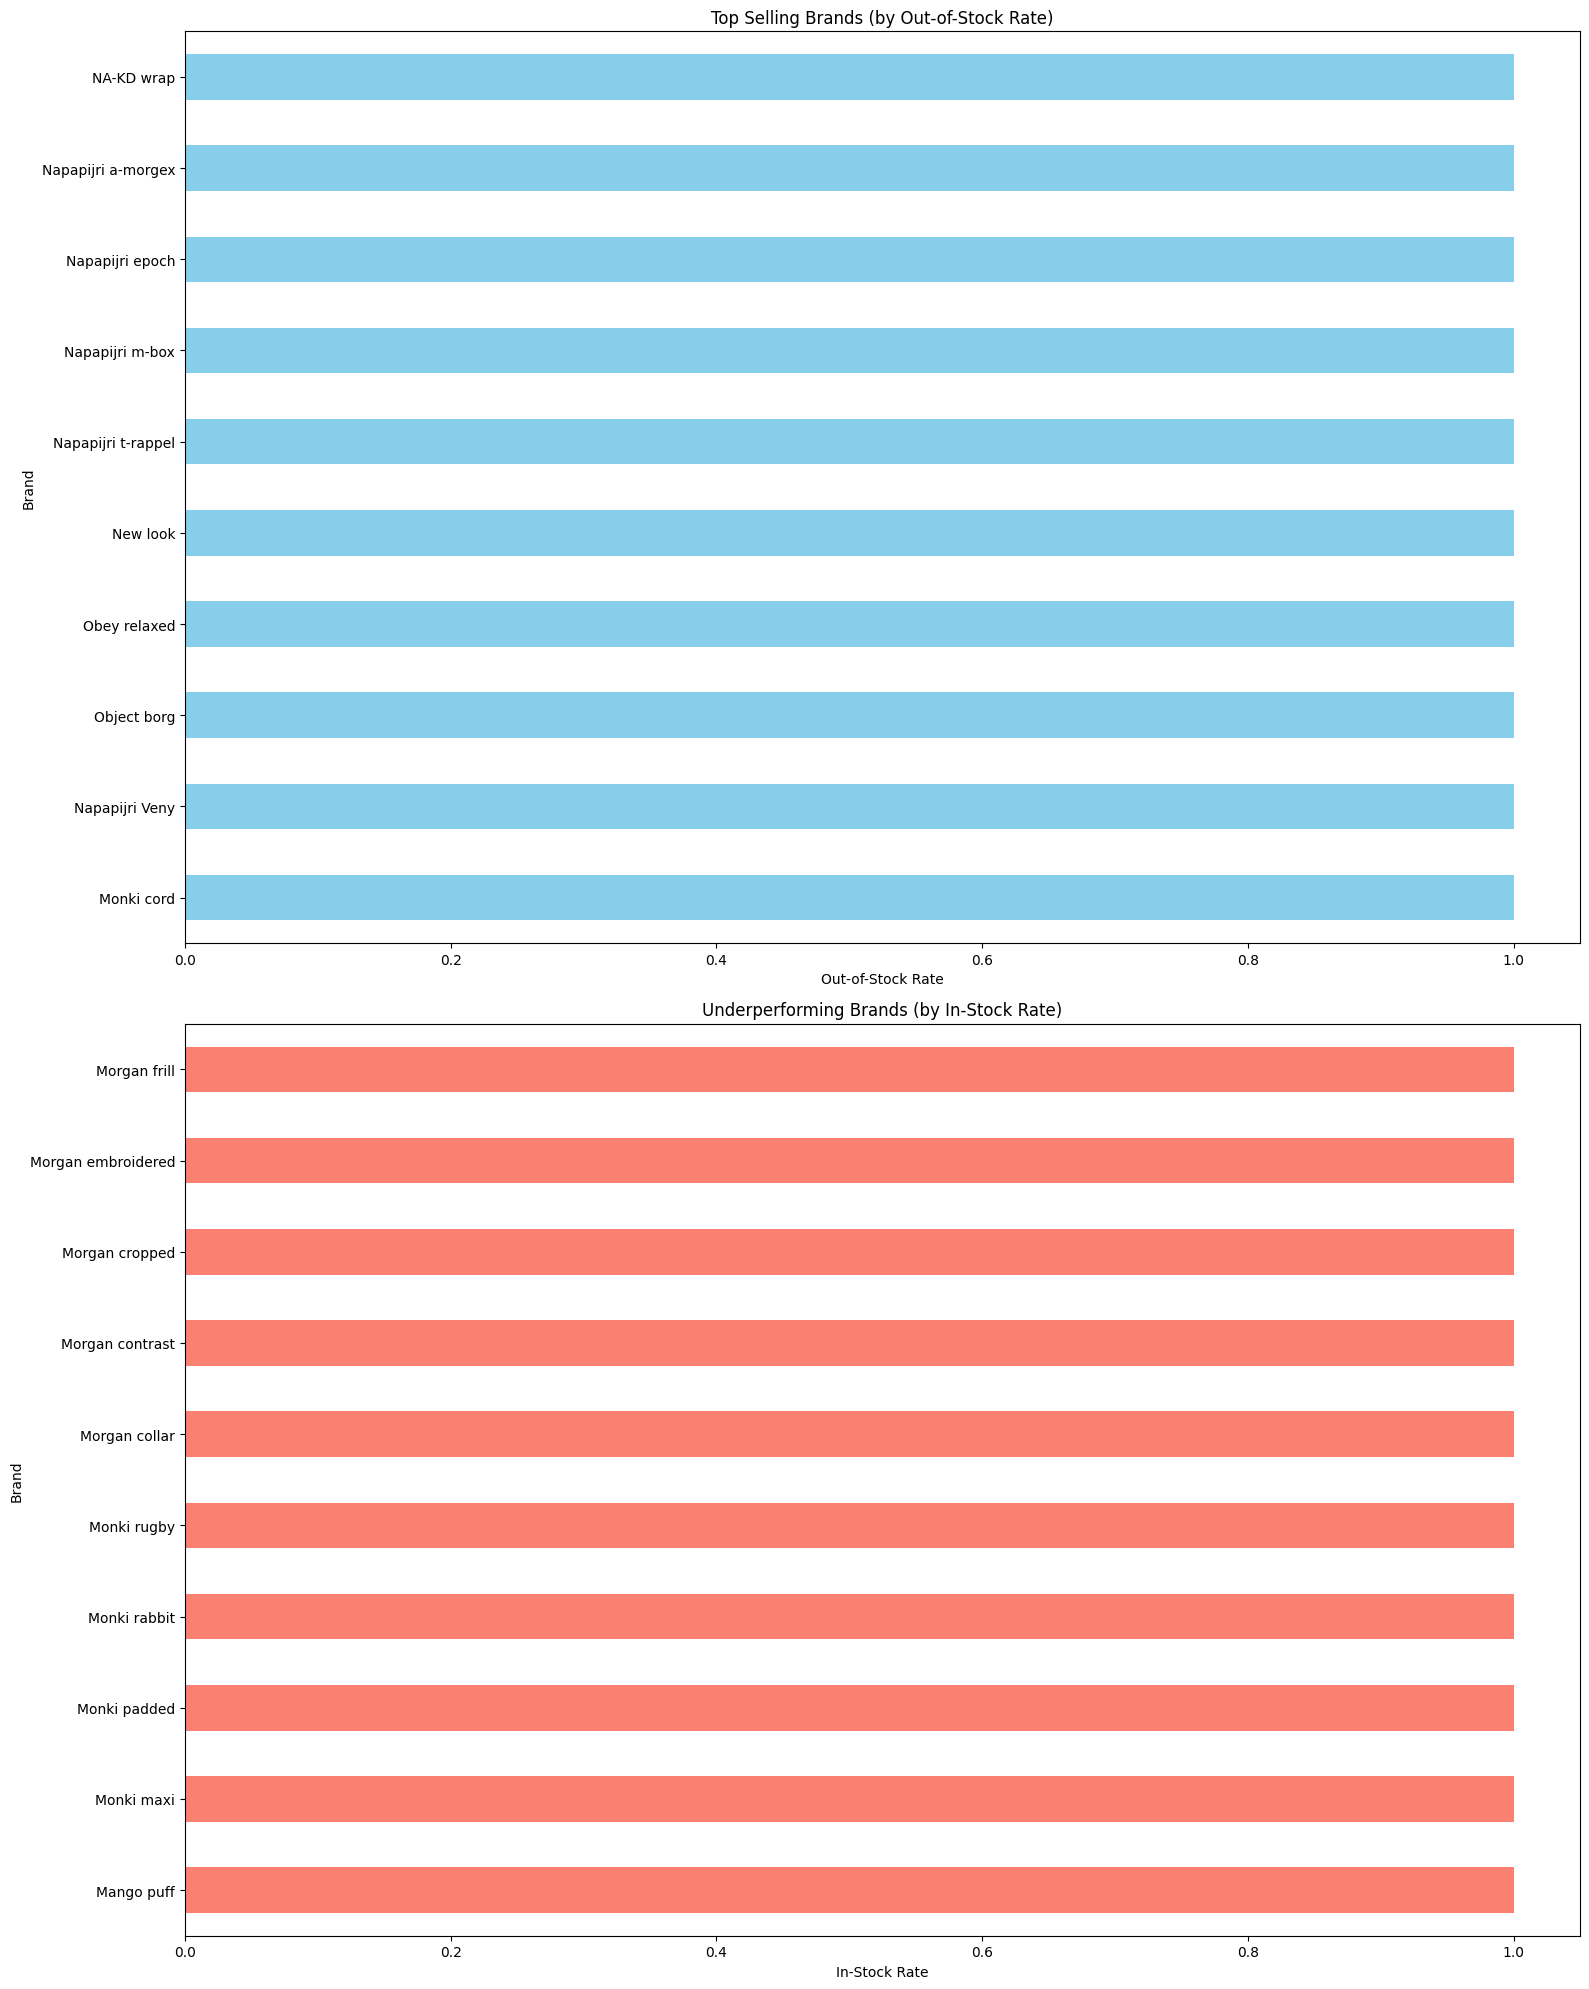

In [31]:
brand_stock_ratio = df.groupby('brand')['stock'].value_counts(normalize=True).unstack()
brand_stock_ratio['out_of_stock_rate'] = brand_stock_ratio.get('Out of stock', 0)
brand_stock_ratio['in_stock_rate'] = brand_stock_ratio.get('In stock', 0)

# Prepare data
top_sellers = brand_stock_ratio.sort_values(by='out_of_stock_rate', ascending=False).head(10)
underperformers = brand_stock_ratio.sort_values(by='in_stock_rate', ascending=False).head(10)

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 20))

# Plot top sellers
top_sellers['out_of_stock_rate'].plot(
    kind='barh',
    ax=axes[0],
    color='skyblue',
    title='Top Selling Brands (by Out-of-Stock Rate)'
)
axes[0].set_xlabel('Out-of-Stock Rate')
axes[0].set_ylabel('Brand')

# Plot underperformers
underperformers['in_stock_rate'].plot(
    kind='barh',
    ax=axes[1],
    color='salmon',
    title='Underperforming Brands (by In-Stock Rate)'
)
axes[1].set_xlabel('In-Stock Rate')
axes[1].set_ylabel('Brand')

plt.tight_layout()
plt.show()

In [ ]:
#creating a copy of the dataset then filtering it to include only items that are in stock, saving it to a new DataFrame and csv file
df_in_stock = df[df['stock'] == 'In stock'].copy()
df_in_stock.to_csv('products_asos_in_stock.csv', index=False)

